# Customer Feedback Text Analysis

This notebook analyzes open-text customer feedback from the experiment.

Goals:
- understand customer sentiment
- identify recurring themes
- detect differences between control and treatment groups

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/experiment_data_cleaned.csv")

df.shape

(647, 15)

## Inspect Customer Comments

The dataset contains open-text feedback from post-call surveys in the `LTR_COMMENT` column.

We first inspect a few comments to understand the type of feedback customers provide.

In [2]:
df["LTR_COMMENT"].dropna().sample(10)

637                                   Very helpful staff
383    Lee who came to install my port for the hun wa...
231    The CS agent and engineer were superb. Install...
91     Easy to join company. With the most friendly a...
69          Extremely helpful engineer on visit Jo 32725
281                Very friendly staff and accommodating
399                              Great customer service.
33     Up and running less than 24h. Fun friendly per...
228    Lady was so nice on the phone as I don¬"t know...
542    After placing an order online with free instal...
Name: LTR_COMMENT, dtype: str

## Comment Availability

We check how many survey responses contain usable open-text feedback.

In [3]:
df["LTR_COMMENT"].notna().sum()

np.int64(482)

## Comment Length Analysis

We calculate the length of customer comments to understand how detailed the feedback is.

In [4]:
df["comment_length"] = df["LTR_COMMENT"].fillna("").str.len()

df["comment_length"].describe()

count     647.000000
mean       89.621329
std       144.310200
min         0.000000
25%         0.000000
50%        37.000000
75%       115.500000
max      1359.000000
Name: comment_length, dtype: float64

## Comment Length Distribution

We visualize the distribution of comment lengths to understand
how detailed customer feedback tends to be.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

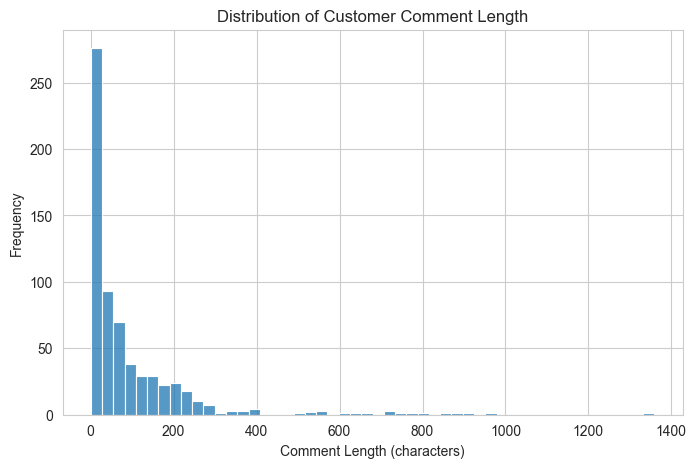

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["comment_length"],
    bins=50
)

plt.title("Distribution of Customer Comment Length")
plt.xlabel("Comment Length (characters)")
plt.ylabel("Frequency")

plt.savefig("../outputs/figures/comment_length_distribution.png", dpi=300)

plt.show()

## Create Clean Comment Dataset

We remove rows with empty comments to create a dataset suitable
for text analysis.

In [8]:
comments_df = df[df["LTR_COMMENT"].notna()].copy()

comments_df.shape

(482, 16)

## Basic Text Cleaning

Before applying NLP methods, we normalize the text by:

- converting to lowercase
- removing punctuation
- removing extra whitespace

In [9]:
import re

def clean_text(text):
    
    text = text.lower()                     # lowercase
    text = re.sub(r"[^\w\s]", "", text)     # remove punctuation
    text = re.sub(r"\s+", " ", text).strip() # remove extra spaces
    
    return text

comments_df["clean_comment"] = comments_df["LTR_COMMENT"].apply(clean_text)

comments_df[["LTR_COMMENT", "clean_comment"]].sample(10)

,LTR_COMMENT,clean_comment
613,We have no experience yet. Installation on Jun...,we have no experience yet installation on june...
158,Charlotta was very helpful,charlotta was very helpful
257,I've been happy with the service from employee...,ive been happy with the service from employees...
352,The experience is really good. The price can b...,the experience is really good the price can be...
322,I have had to call company everyday. 15/05/23 ...,i have had to call company everyday 150523 spo...
182,The process was pretty easy,the process was pretty easy
231,The CS agent and engineer were superb. Install...,the cs agent and engineer were superb installa...
265,"Excellent service from the get go, the gent I ...",excellent service from the get go the gent i s...
236,Very polite and friendly,very polite and friendly
521,Communications terrible,communications terrible


## Filter Very Short Comments

Very short comments may not contain meaningful feedback.
We remove comments shorter than 5 characters.

In [10]:
comments_df = comments_df[comments_df["clean_comment"].str.len() > 5]

comments_df.shape

(478, 17)

## Save Cleaned Comment Dataset

After cleaning and filtering comments, we save the processed
dataset so that downstream NLP analysis can load it directly.

In [11]:
comments_df.to_csv(
    "../data/processed/customer_feedback_comments_cleaned.csv",
    index=False
)

In [12]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

comments_df["sentiment_score"] = comments_df["clean_comment"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

comments_df[["clean_comment", "sentiment_score"]].sample(10)

,clean_comment,sentiment_score
330,i have found that the service so far has been ...,-0.5831
315,fantastic customer experience,0.5574
399,great customer service,0.6249
522,very efficient and friendly,0.7620
220,very polite and professional people who sorted...,0.0000
377,very good customer service from agent and she ...,0.8514
106,friendly and good customer service plus a suit...,0.8402
324,the service was fabulous,0.5267
104,i ordered my package online which was meant to...,0.1154
197,good services,0.4404


## Sentiment Classification

We convert sentiment scores into categorical labels:

- positive
- neutral
- negative

In [13]:
def classify_sentiment(score):
    
    if score >= 0.05:
        return "positive"
    
    elif score <= -0.05:
        return "negative"
    
    else:
        return "neutral"


comments_df["sentiment_label"] = comments_df["sentiment_score"].apply(classify_sentiment)

comments_df["sentiment_label"].value_counts()

sentiment_label
positive    361
negative     71
neutral      46
Name: count, dtype: int64

## Sentiment by Experiment Group

We compare the distribution of sentiment between the control and
treatment groups to understand whether the decision-support script
affected the emotional tone of customer feedback.

In [14]:
pd.crosstab(
    comments_df["experiment_group"],
    comments_df["sentiment_label"]
)

sentiment_label,negative,neutral,positive
experiment_group,,,
control,42,25,217
treatment,29,21,144


Control
- Positive ≈ 76%
- Negative ≈ 15%
- Neutral ≈ 9%

Treatment
- Positive ≈ 74%
- Negative ≈ 15%
- Neutral ≈ 11%

The new script does not appear to significantly change
the emotional tone of customer feedback.

## Sentiment Distribution by Experiment Group

We visualize the sentiment distribution for control and treatment groups.

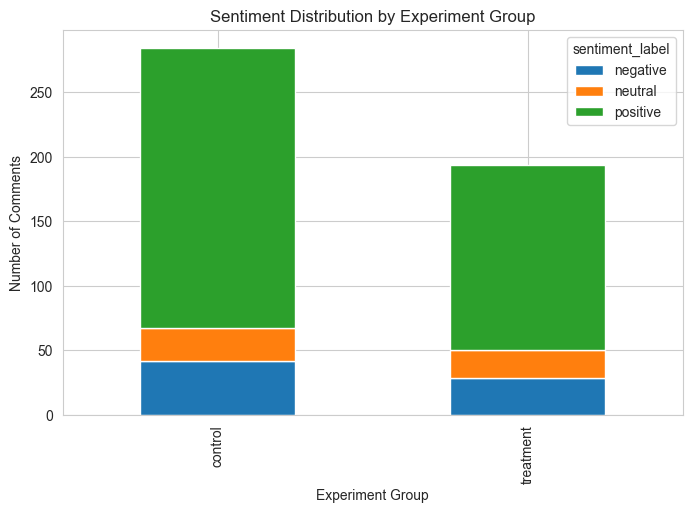

In [15]:
sentiment_counts = pd.crosstab(
    comments_df["experiment_group"],
    comments_df["sentiment_label"]
)

sentiment_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Sentiment Distribution by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Number of Comments")

plt.savefig("../outputs/figures/sentiment_by_experiment_group.png", dpi=300)

plt.show()

## Sentiment by Customer Segment and Experiment Group

The script may impact customer segments differently.  
We examine sentiment distribution for VOLT vs non-VOLT customers across experiment groups.

In [18]:
comments_df["volt_segment"] = comments_df["VOLT_FLAG"].apply(
    lambda x: "volt" if x == "yes" else "non_volt"
)

In [19]:
comments_df["volt_segment"].value_counts()

volt_segment
non_volt    278
volt        200
Name: count, dtype: int64

In [20]:
sentiment_segment = pd.crosstab(
    [comments_df["volt_segment"], comments_df["experiment_group"]],
    comments_df["sentiment_label"]
)

sentiment_segment

sentiment_label                negative  neutral  positive
volt_segment experiment_group                             
non_volt     control                 22       12       111
             treatment               20       11       102
volt         control                 20       13       106
             treatment                9       10        42

- For non-VOLT customers, the new script does not change sentiment.
Customer reactions remain almost identical.
- For VOLT customers, positive sentiment decreases slightly in the
treatment group, while neutral feedback increases.

## Sentiment Distribution by Customer Segment and Experiment

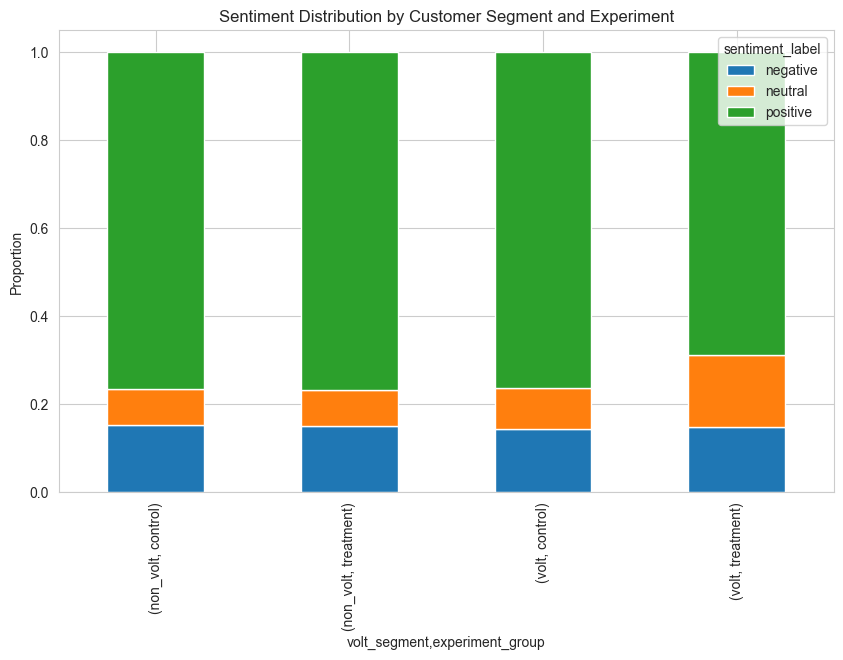

In [21]:
segment_sentiment = pd.crosstab(
    [comments_df["volt_segment"], comments_df["experiment_group"]],
    comments_df["sentiment_label"],
    normalize="index"
)

segment_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Sentiment Distribution by Customer Segment and Experiment")
plt.ylabel("Proportion")

plt.savefig("../outputs/figures/sentiment_by_segment.png", dpi=300)

plt.show()

## Frequent Words in Customer Feedback

We analyze the most common words used in customer comments
to understand recurring themes in feedback.

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30
)

X = vectorizer.fit_transform(comments_df["clean_comment"])

word_counts = pd.DataFrame(
    {
        "word": vectorizer.get_feature_names_out(),
        "count": X.toarray().sum(axis=0)
    }
).sort_values(by="count", ascending=False)

word_counts.head(15)

,word,count
23,service,160
15,helpful,110
12,good,89
3,company,80
5,customer,78
11,friendly,62
19,phone,46
14,great,43
20,polite,34
6,easy,32


Customer feedback focuses heavily on agent behaviour,
with words such as “helpful”, “friendly”, and “polite”
appearing frequently.<br>

This suggests that perceived service quality is driven
more by agent interaction than by technical broadband factors.

## Frequent Words by Experiment Group

In [24]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30
)

control_comments = comments_df[
    comments_df["experiment_group"] == "control"
]["clean_comment"]

treatment_comments = comments_df[
    comments_df["experiment_group"] == "treatment"
]["clean_comment"]

X_control = vectorizer.fit_transform(control_comments)

control_words = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X_control.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

control_words.head(10)

,word,count
24,service,98
10,good,65
13,helpful,62
4,customer,52
2,company,52
9,friendly,36
19,phone,26
20,polite,24
12,great,22
8,excellent,20


In [25]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30
)

X_treatment = vectorizer.fit_transform(treatment_comments)

treatment_words = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X_treatment.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

treatment_words.head(10)

,word,count
23,service,62
14,helpful,48
2,company,28
3,customer,26
9,friendly,26
10,good,24
12,great,21
18,phone,20
26,team,18
24,set,15


Across satisfaction scores, sentiment analysis, and language patterns,
there is little evidence that the new decision-support script
significantly changed customer perceptions.

## Language Drivers of Negative Feedback

In [26]:
negative_comments = comments_df[
    comments_df["sentiment_label"] == "negative"
]["clean_comment"]

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X_neg = vectorizer.fit_transform(negative_comments)

neg_words = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X_neg.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

neg_words

,word,count
1,company,24
13,service,22
2,contract,17
3,customer,15
16,told,14
11,phone,10
12,said,10
10,ive,9
5,did,9
4,day,9


Customer dissatisfaction appears to be driven primarily by
contract issues, service problems, and miscommunication,
rather than by agent behaviour.<br>

Positive feedback frequently references agent friendliness
and helpfulness, suggesting that customer service interactions
are generally perceived positively.

## Topic Discovery in Customer Feedback

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(comments_df["clean_comment"])

nmf = NMF(n_components=5, random_state=42)

W = nmf.fit_transform(X)
H = nmf.components_

words = vectorizer.get_feature_names_out()

topics = []

for topic_idx, topic in enumerate(H):
    top_words = [words[i] for i in topic.argsort()[-10:]]
    topics.append(top_words)

topics

[['quick',
  'company',
  'brilliant',
  'happy',
  'broadband',
  'new',
  'fantastic',
  'excellent',
  'customer',
  'service'],
 ['agent',
  'informative',
  'process',
  'staff',
  'spoke',
  'phone',
  'polite',
  'extremely',
  'patient',
  'helpful'],
 ['response',
  'communication',
  'really',
  'sky',
  'package',
  'value',
  'easy',
  'price',
  'service',
  'good'],
 ['help',
  'explained',
  'polite',
  'professional',
  'really',
  'quick',
  'easy',
  'staff',
  'efficient',
  'friendly'],
 ['job',
  'got',
  'easy',
  'help',
  'engineer',
  'set',
  'quick',
  'service',
  'price',
  'great']]

| Topic | Theme                       |
| ----- | --------------------------- |
| 1     | Overall satisfaction        |
| 2     | Agent professionalism       |
| 3     | Pricing / package decisions |
| 4     | Explanation clarity         |
| 5     | Installation experience     |


## Topic Themes in Customer Feedback

In [28]:
topic_labels = [
    "Overall Service Satisfaction",
    "Agent Professionalism",
    "Pricing and Package Selection",
    "Explanation and Support",
    "Installation Experience"
]

topic_counts = W.argmax(axis=1)

topic_df = pd.DataFrame({
    "topic": topic_counts
})

topic_df["topic_name"] = topic_df["topic"].map(dict(enumerate(topic_labels)))

topic_df["topic_name"].value_counts()

topic_name
Installation Experience          111
Explanation and Support          108
Agent Professionalism             94
Pricing and Package Selection     83
Overall Service Satisfaction      82
Name: count, dtype: int64

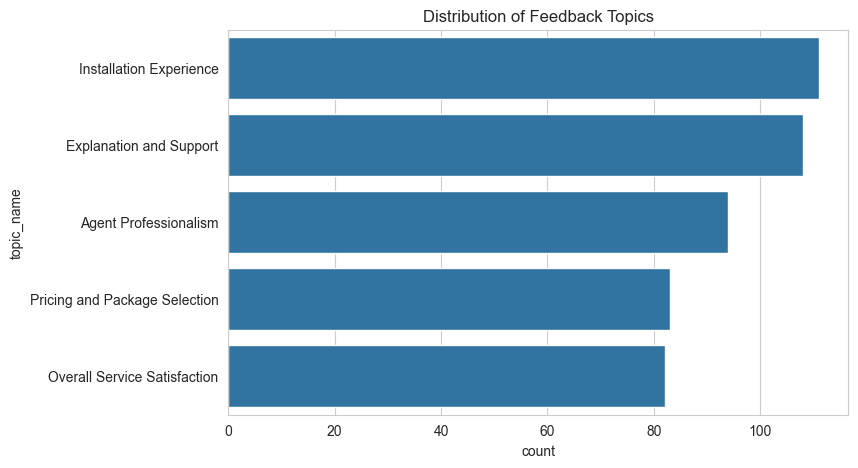

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    y=topic_df["topic_name"],
    order=topic_df["topic_name"].value_counts().index
)

plt.title("Distribution of Feedback Topics")

plt.savefig("../outputs/figures/topic_distribution.png", dpi=300)

plt.show()

| Topic                         | Count |
| ----------------------------- | ----- |
| Installation Experience       | 111   |
| Explanation and Support       | 108   |
| Agent Professionalism         | 94    |
| Pricing and Package Selection | 83    |
| Overall Service Satisfaction  | 82    |


Operational service experience may matter more than decision-support messaging.

## Topic Distribution by Experiment Group

In [30]:
comments_df["topic"] = topic_counts

topic_experiment = pd.crosstab(
    comments_df["topic"],
    comments_df["experiment_group"]
)

topic_experiment

experiment_group,control,treatment
topic,,
0,50,32
1,55,39
2,59,24
3,61,47
4,59,52


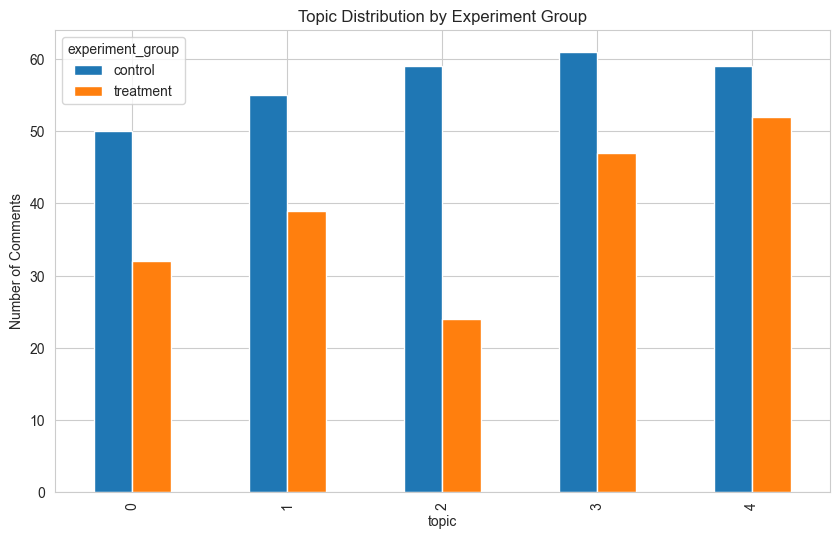

In [31]:
topic_experiment.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Topic Distribution by Experiment Group")
plt.ylabel("Number of Comments")

plt.savefig("../outputs/figures/topic_by_experiment.png", dpi=300)

plt.show()

The decision-support script did not significantly improve customer satisfaction scores or sentiment. However, topic analysis suggests a modest shift in customer feedback toward explanation and support themes in the treatment group. This indicates that while the script may influence communication clarity, it does not appear to meaningfully impact overall customer satisfaction.